# Transcript Cleaning Pipeline 
## Isolated into one notebook
### Built based upon McCray Metadata


In [116]:
import pandas as pd
import numpy as np
import re, ast, json, csv
from utils.constants import Paths
from utils.ocr_cleaning import OCR_Clean, OCR_Check
import nltk
from nltk.corpus import words, PlaintextCorpusReader

### Get original metadata

In [117]:
# Get original metadata
mccray = pd.read_csv(r"../data/mccray/original_data/McCray metadata.csv")
print(list(mccray))

def save_csv(df, title):
    df.to_csv(title,
          index=False,
          encoding='utf-8',
          quoting=csv.QUOTE_NONNUMERIC,   
          escapechar='\\',
          lineterminator='\n')

# nltk download
# nltk.download('words')
english_vocab = set(w.lower() for w in words.words())

wordlists = PlaintextCorpusReader('../data/mccray', 'combined_words_corpus.txt')

print(len(mccray))

['Title', 'Creator', 'Contributors', 'Date', 'Approximate Date', 'Source', 'Subject', 'Local Subject', 'S.C. County', 'Description', 'Extent', 'Digital Collection', 'Website', 'Contributing Institution', 'Rights', 'Time Period', 'Geographic Location', 'Language', 'Digitization Specifications', 'Date Digital', 'Type', 'Format', 'Media Type', 'Identifier', 'Note', 'Digital Assistant', 'Transcript', 'OCLC number', 'Date created', 'Date modified', 'Reference URL', 'CONTENTdm number', 'CONTENTdm file name', 'CONTENTdm file path']
19329


### Handle the fields / basic standardization

In [118]:
# Add 'Year' field
mccray['Year'] = mccray['Date']
mccray['Year'] = mccray['Year'].apply(lambda x: str(x))
mccray['Year'] = mccray['Year'].apply(lambda x: re.sub(r'[^0-9]+', "", x))
mccray['Year'] = mccray['Year'].apply(lambda x: x[:4])

# Copy "Transcript" Column as "Original Transcript" & Remove "Transcript" Column
mccray['Original Transcript'] = mccray['Transcript'] 
mccray = mccray.drop('Transcript', axis=1)  

# Replace empty transcripts with na
mccray['Original Transcript'] = mccray['Original Transcript'].fillna('').apply(lambda x: x.strip() if isinstance(x, str) else '')

# Add "Original Len" Column for lengths
mccray['Original Len'] = mccray['Original Transcript'].str.replace(' ', '').str.len()


### Determining messiness and provide details on transcripts

In [119]:
# Helper to find sequences using regex pattern, allowing for exceptions (created for some patterers in OCR_Clean class)
def find_sequences(pattern, text, exceptions=[]):
    candidates = re.findall(pattern, str(text))
    flagged = []
    for candidate in candidates:
        if not any(re.match(exc, candidate) for exc in exceptions):
            flagged.append(candidate)
    return flagged

# Updated data cleaning metrics with new structure
transcript_col = 'Original Transcript'

# Individual pattern detection (Boolean columns)
mccray['Special Pattern'] = mccray[transcript_col].apply(lambda x: len(find_sequences(OCR_Clean.special_pattern, x)) > 0)
mccray['General Pattern'] = mccray[transcript_col].apply(lambda x: len(find_sequences(OCR_Clean.general_pattern, x, OCR_Clean.general_exceptions)) > 0)
mccray['Repeat Chars'] = mccray[transcript_col].apply(lambda x: len(find_sequences(OCR_Clean.letter_pattern, x)) > 0)
mccray['Short/No Transcript'] = mccray['Original Len'] < 20

# Overall messiness/quaility indicator
mccray['Quality'] = ~(mccray['Special Pattern'] | mccray['General Pattern'] | mccray['Repeat Chars'] | mccray['Short/No Transcript'])

# Issue Types (List of Strings)
def get_issue_types(row):
    types = []
    if row['Special Pattern']:
        types.append('Special Char Artifacts')
    if row['General Pattern']:
        types.append('General Artifacts')
    if row['Repeat Chars']:
        types.append('Repeat Chars')
    if row['Original Len'] == 0:
        types.append('Empty Transcript')
    elif row['Short/No Transcript']:
        types.append('Low Char Count')
    return types

mccray['Issue Types'] = mccray.apply(get_issue_types, axis=1)

# Detected Artifacts (List of Strings)
def get_detected_artifacts(text):
    artifacts = []
    # Add special pattern artifacts
    artifacts.extend(find_sequences(OCR_Clean.special_pattern, text))
    # Add general pattern artifacts
    artifacts.extend(find_sequences(OCR_Clean.general_pattern, text, OCR_Clean.general_exceptions))
    # Add repeat character sequences
    artifacts.extend(find_sequences(OCR_Clean.letter_pattern, text))
    return artifacts

mccray['Detected Artifacts'] = mccray[transcript_col].apply(get_detected_artifacts)

# Actual isolation - October Sprint

In [120]:
print(list(mccray), "\n")

# Remove [].cpd documents (previously captured by empty docs, but this covers clear seperation / reason behind empty transcripts)
mccray_cpd = mccray[mccray['CONTENTdm file name'].str.split('.').str[1] == 'cpd']
mccray_jp2 = mccray[mccray['CONTENTdm file name'].str.split('.').str[1] != 'cpd']

# Remove empty documents (where Original Transcript is empty or NaN)
mccray_pure_empty = mccray_jp2[mccray_jp2['Original Transcript'].isna() | (mccray_jp2['Original Transcript'].str.strip() == '')]
mccray_no_empty = mccray_jp2[mccray_jp2['Original Transcript'].notna() & (mccray_jp2['Original Transcript'].str.strip() != '')]

# Remove repeated documents (same Original Transcript content, different IDs)
# Keep first occurrence of each unique transcript
mccray_repeated = mccray_no_empty[mccray_no_empty.duplicated(subset=['Original Transcript'], keep=False)]
mccray_no_repeat = mccray_no_empty.drop_duplicates(subset=['Original Transcript'], keep='first')


['Title', 'Creator', 'Contributors', 'Date', 'Approximate Date', 'Source', 'Subject', 'Local Subject', 'S.C. County', 'Description', 'Extent', 'Digital Collection', 'Website', 'Contributing Institution', 'Rights', 'Time Period', 'Geographic Location', 'Language', 'Digitization Specifications', 'Date Digital', 'Type', 'Format', 'Media Type', 'Identifier', 'Note', 'Digital Assistant', 'OCLC number', 'Date created', 'Date modified', 'Reference URL', 'CONTENTdm number', 'CONTENTdm file name', 'CONTENTdm file path', 'Year', 'Original Transcript', 'Original Len', 'Special Pattern', 'General Pattern', 'Repeat Chars', 'Short/No Transcript', 'Quality', 'Issue Types', 'Detected Artifacts'] 



In [121]:
# print counts
print(f'cpd count: {len(mccray_cpd)} / {len(mccray)} -- {len(mccray_cpd)} docs are "cpd" / collections')
print(f'Empty count: {len(mccray_pure_empty)} / {len(mccray)} -- {len(mccray_pure_empty)} docs need rescanned due null content')
print(f'Repeated count: {len(mccray_repeated)} / {len(mccray_no_empty)} -- {len(mccray_repeated)} docs need are not needed due to being repeated content') 

# save empty and repeated
save_csv(mccray_cpd, "../data/mccray/october_sprint/D_mcc_cpd.csv")
save_csv(mccray_pure_empty, "../data/mccray/october_sprint/D_mcc_0.csv")
save_csv(mccray_repeated, "../data/mccray/october_sprint/D_mcc_rep.csv")

mccray = mccray_no_repeat.copy()

cpd count: 303 / 19329 -- 303 docs are "cpd" / collections
Empty count: 4385 / 19329 -- 4385 docs need rescanned due null content
Repeated count: 390 / 14641 -- 390 docs need are not needed due to being repeated content


In [ ]:
# Save all OG Transcripts w/ Quality=True to 'Semi-clean Transcripts'
sc_col = 'D_mcc_cleaned_v2'
mccray[sc_col] = mccray['Original Transcript'].where(mccray['Quality'] == True, "") # intially normalized the spacing here, but holding off until transcripts w/ issues are combined

### Pre proccessing to turn OG transcripts w/ issues into semi-clean transcripts

In [123]:
# Pattern removal and condence patterns for semi-cleaning
mccray['Cleaning'] = mccray['Original Transcript'].where(
    (mccray['Quality'] == False) & (mccray['Short/No Transcript'] == False), ""
)
# mccray['Cleaning'] = mccray['Cleaning'].apply(lambda x: re.sub(OCR_Clean.letter_pattern, r'\1', x))
mccray['Cleaning'] = mccray['Cleaning'].apply(lambda x: re.sub(OCR_Clean.special_pattern, "", x))
# mccray['Cleaning'] = mccray['Cleaning'].apply(lambda x: re.sub(OCR_Clean.general_pattern, "", x))

def combine_transcripts(row):
    if row[sc_col] != '':
        return row[sc_col]
    elif row['Cleaning'] != '':
        return row['Cleaning']
    else:
        return ''

# Combine the columns which were the most clean, and placed in semi-clean, with the newly 'Cleaning' column
mccray[sc_col] = mccray.apply(combine_transcripts, axis=1)

mccray = mccray.drop('Cleaning', axis=1)

### Basic Cleaning / standardization / Preprocessing of Semi-clean

In [124]:
# Clean spacing (with auto newlining)
def normalize_spaces(text):
    return re.sub(r" {2,}", lambda m: "\n" if len(m.group(0)) > 3 else " ", text)

mccray[sc_col] = mccray[sc_col].apply(normalize_spaces)

## Determining where re-scans are needed based upon '% English' 
### Detect percentage of 'Semi-clean Transcripts' that appears to be English 
##### October Sprint

In [ ]:
# # Add % english column
# def percent_english_nltk(text):
#     tokens = re.findall(r"[A-Za-z]+", text.lower())
#     if not tokens:
#         return 0
#     real = [t for t in tokens if t in english_vocab]
#     return 100 * len(real) / len(tokens)

# corpus_set = set(w.lower() for w in wordlists.words())

# def percent_english_nltk_corpus(text, wordlists):
#     # Extract words (letters only)
#     tokens = re.findall(r"[A-Za-z]+", text.lower())
#     if not tokens:
#         return 0.0

#     # Count words that appear in the corpus
#     real = [t for t in tokens if t in english_vocab]

#     return 100 * len(real) / len(tokens)

# # Apply to semi-clean column
# print("Detecting language percentage for sc col...")
# mccray['% English (base ntlk)'] = mccray['Original Transcript'].apply(percent_english_nltk)
# mccray['% Semi-clean English (base ntlk)'] = mccray[sc_col].apply(percent_english_nltk)

# mccray['% English'] = mccray['Original Transcript'].apply(lambda x: percent_english_nltk_corpus(x, corpus_set))
# mccray['% Semi-clean English'] = mccray[sc_col].apply(lambda x: percent_english_nltk_corpus(x, corpus_set))

Detecting language percentage for sc col...


In [ ]:
# # Isolate appearances where english word % not high enough
# ### Held off until semi-cleaning
# per = 60
# mccray_high_english = mccray[mccray['% English'] > per]          
# mccray_low_english = mccray[mccray['% English'] <= per]          
# mccray_no_detection = mccray[mccray['% English'].isna()]       

# # Print % English for 'CONTENTdm number' == 
# target_numbers = [998, 1000, 1001, 1003]

# print("% English for specific CONTENTdm numbers:")
# print("-" * 50)

# for num in target_numbers:
#     matching_rows = mccray[mccray['CONTENTdm number'] == num]
    
#     if not matching_rows.empty:
#         for idx, row in matching_rows.iterrows():
#             english_pct = row.get('% English', 'Not calculated')
#             title = row.get('Title', 'No title')[:50] + ('...' if len(str(row.get('Title', ''))) > 50 else '')
            
#             print(f"CONTENTdm {num}: {english_pct}% English")
#             print(f"  Title: {title}")
#             print(f"  Semi-clean preview: {str(row[sc_col])[:100]}...")
#             print()
#     else:
#         print(f"CONTENTdm {num}: NOT FOUND in current dataset")
#         print()

% English for specific CONTENTdm numbers:
--------------------------------------------------
CONTENTdm 998: 49.09090909090909% English
  Title: The Lighthouse and Informer paper notes, October 1...
  Semi-clean preview: J^AAyuAJ- laa-Ji -
C$UZ^lt?terV) - Bryb /&lt;?, jg^ I l-O: f stfjhL fcul^d kjp^v1 taw 3&ia& cOaj jjj...

CONTENTdm 1000: 48.148148148148145% English
  Title: The Lighthouse and Informer paper notes, February ...
  Semi-clean preview: top ." qqu UJachdsooih 2)&u?vi l G&rmfrvu^fo&gt;7c6 ' "^fiA^t -fLtuLojr $a^a 2duM^Ur^ CAjjtLcm " A4-...

CONTENTdm 1001: 45.1219512195122% English
  Title: The Lighthouse and Informer paper notes, February ...
  Semi-clean preview: p I rlyAjxJi CUx Uaama^ ^ Clx^ilwterv) *-.fat, H CwMvvu. PVLtTL rCLA^ %uJy tf
Vl O^- ^U^M^ UAaAtClU ...

CONTENTdm 1003: 54.54545454545455% English
  Title: The Lighthouse and Informer paper notes, February ...
  Semi-clean preview: -7 Jy^U^xyMJSLs-; ciaviA- Q-iA^(yry7ou^j
OiL^n to, /tf&lt;/3 1*1 N. v ' &gt;
7 -C

In [ ]:
# # print counts
# print(f'% English =< 70: {len(mccray_low_english)} / {len(mccray)} -- {len(mccray_low_english)} docs need rescanned due to non-english artifacts')
# print(f'% English no dect: {len(mccray_no_detection)} / {len(mccray)}')

# print("\n Check that % pulled add up: ", len(mccray_low_english) + len(mccray_no_detection) + len(mccray_high_english))
# print(f'% English high detect (new main csv count): {len(mccray_high_english)}')


% English =< 70: 1109 / 14427 -- 1109 docs need rescanned due to non-english artifacts
% English no dect: 0 / 14427

 Check that % pulled add up:  14427
% English high detect (new main csv count): 13318


In [ ]:
# # save
# # save_csv(mccray_low_english, f"../data/mccray/october_sprint/D_mcc_%lt{per}.csv")

# mccray_high_english

# print(f"len mcc: ", len(mccray))

len mcc:  14427


### Final Cleaning of 'Semi-Clean Transcript' Column 
- ##### Create set of all words from 'Title' Column
- ##### Use this set for spello dict
- ##### Apply spello
- ##### Find more advanced method to normalizing spacing for readablity (less important)

In [129]:
mccray.index = range(2, 2 + len(mccray))
save_csv(mccray, f'{Paths.mccray_folder}/october_sprint/D_mcc_main.csv')
# save_csv(mccray_high_english, f"../data/mccray/october_sprint/D_mcc_%gt{per}.csv")


display(mccray)

,Title,Creator,Contributors,Date,Approximate Date,Source,Subject,Local Subject,S.C. County,Description,...,Repeat Chars,Short/No Transcript,Quality,Issue Types,Detected Artifacts,Semi-clean Transcript,% English (base ntlk),% Semi-clean English (base ntlk),% English,% Semi-clean English
2,Afro-American Newsboy Application signed by Mr...,NaN,"McCray, John Henry, 1910-1987",NaN,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,An application to be a Newsboy for the Afro-Am...,...,False,False,True,[],[],-5491 AFRO-AMERICAN NEWSBOY'S APPLICATION I he...,78.378378,78.378378,78.378378,78.378378
3,Lighthouse Informer receipt,NaN,"McCray, John Henry, 1910-1987",NaN,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,A blank Lighthouse and Informer receipt.,...,False,False,True,[],[],"19 Received from RECEIVED OF ""Shedding Light F...",91.304348,91.304348,91.304348,91.304348
4,"The Lighthouse Solicitor's Record, Home Office...",NaN,"McCray, John Henry, 1910-1987",NaN,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,"A solicitor's record, home office order, and s...",...,False,False,True,[],[],SOLICITOR'S RECORD Name Address City State Amo...,91.666667,91.666667,91.666667,91.666667
5,The Lighthouse Remittance Envelope(Front),NaN,"McCray, John Henry, 1910-1987",NaN,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,The front of a Lighthouse remittance envelope.,...,False,False,True,[],[],Sender's Address Shedding Light For A Growing ...,100.000000,100.000000,100.000000,100.000000
6,"Advertisment, Chicken Special at the Pig Trail...",NaN,"McCray, John Henry, 1910-1987",NaN,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,An ad about the Chicken Special for the Pig Tr...,...,False,False,True,[],[],"Just Telephone Us, Place your order. It'll be ...",84.848485,84.848485,84.848485,84.848485
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14424,"Letter from Mildred Chestnut, Secretary at the...","Chestnut, Mildred (Secretary for Lighthouse an...","McCray, John Henry, 1910-1987",1946-09-27 00:00:00,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,"Letter from Mildred Chestnut, Secretary at the...",...,False,False,False,[Special Char Artifacts],[┬Ñ],"September 27, W46\nfthelyn . Psxkex 163a Line ...",79.661017,79.661017,79.661017,79.661017
14425,Letter from John H. McCray to Mr. Arthur W. Ai...,"McCray, John Henry, 1910-1987","McCray, John Henry, 1910-1987",1946-09-28 00:00:00,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,Letter from John H. McCray to Mr. Arthur W. Ai...,...,False,False,True,[],[],"Sept. 28, 1946\nMX* Ait hoi W* Aiken\n429 Pace...",73.809524,73.809524,73.809524,73.809524
14426,"Letter from John H. McCray to Dr. E. J. Cling,...","McCray, John Henry, 1910-1987","McCray, John Henry, 1910-1987",1946-09-28 00:00:00,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,Letter from John H. McCray to Dr. E. J. Cling ...,...,False,False,False,"[Special Char Artifacts, General Artifacts]","[┬ú&ΓÇó, ┬úΓÇó, \\, \\, ΓÇó, ┬½, ú&ΓÇó]","Sept. 28, 1946\nJ. Cling\n583 King St.\nCharle...",90.476190,90.476190,90.476190,90.476190
14427,Letter from Mrs. E.M. Parker to Mildred Chestn...,"McCray, John Henry, 1910-1987","McCray, John Henry, 1910-1987",1946-09-30 00:00:00,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,Letter from Mrs. E.M. Parker to Mildred Chestn...,...,False,False,False,[Special Char Artifacts],[ΓÇÖ],"loja Line, St.,\nCharleston, S.C\nSept. 30,194...",94.495413,94.444444,94.495413,94.444444


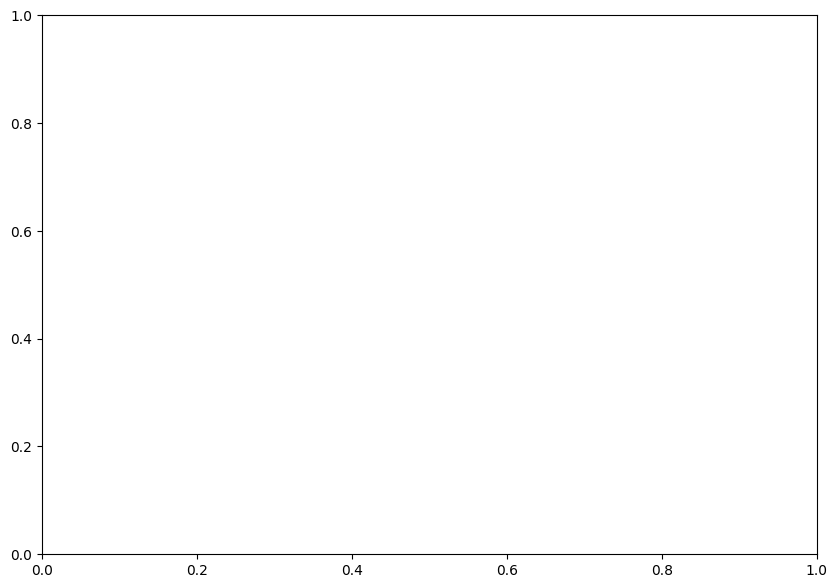

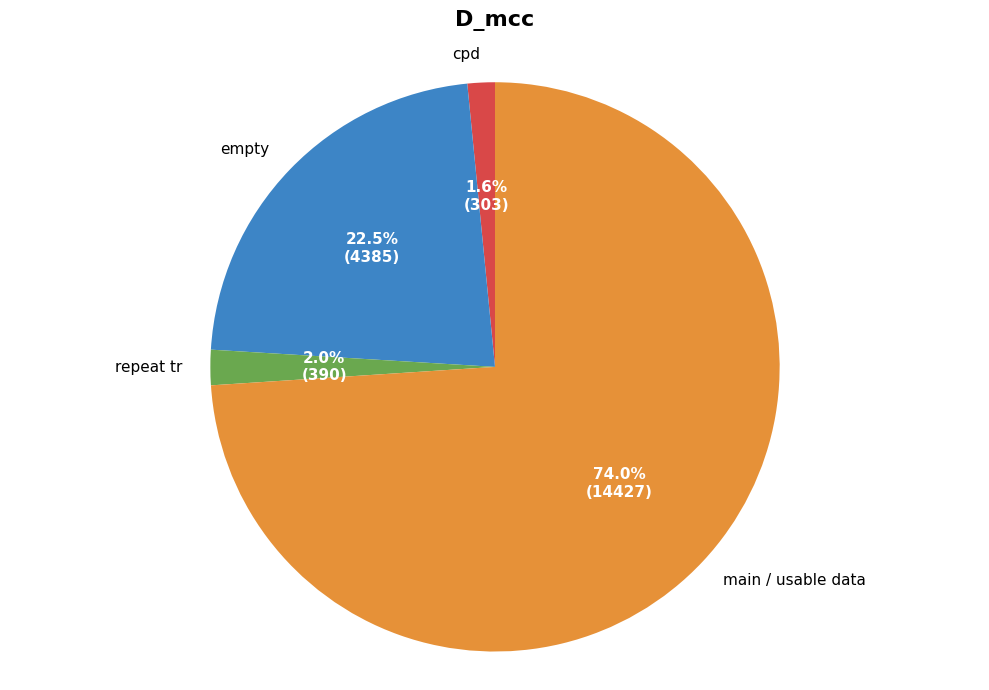

In [134]:
import matplotlib.pyplot as plt

# data
categories = ['cpd', 'empty', 'repeat tr', 'main / usable data']
values = [len(mccray_cpd), len(mccray_pure_empty), len(mccray_repeated), len(mccray)]

#  Create pie chart
fig, ax = plt.subplots(figsize=(10, 7))

# Create pie chart
fig, ax = plt.subplots(figsize=(10, 7))

# Create the pie chart with customizations
wedges, texts, autotexts = ax.pie(
    values,
    labels=categories,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100.*sum(values))})',  # Show percentages and counts
    startangle=90,       # Start from top
    colors=['#d94848', '#3d85c6', '#6aa84f', '#e69138'],
    textprops={'fontsize': 11}
)

# Enhance the percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Add title
plt.title('D_mcc', fontsize=16, fontweight='bold', pad=20)

# Equal aspect ratio ensures circular pie
ax.axis('equal')

# # Optional: Add a legend
# plt.legend(wedges, categories, title="Categories", loc="best", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()


ValueError: 'labels' must be of length 'x', not 4

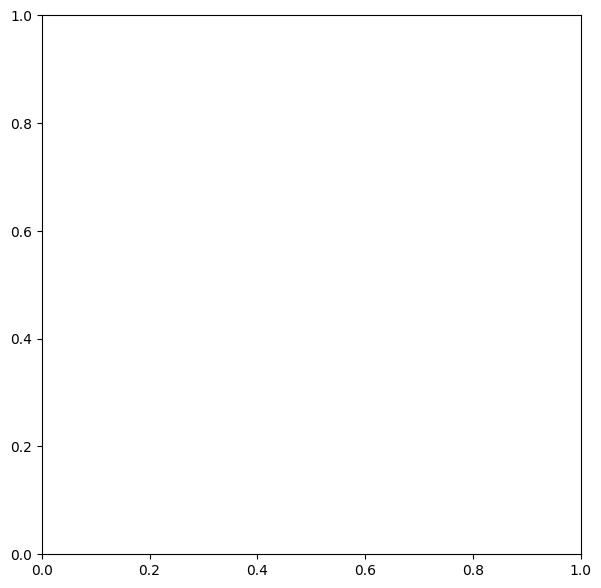

In [131]:
# data
categories = ['cpd', 'empty', 'repeat tr', 'main']
values = [len(mccray_cpd), len(mccray_pure_empty), len(mccray_repeated), ]

#  Create pie chart
fig, ax = plt.subplots(figsize=(10, 7))

# Create the pie chart with customizations
wedges, texts, autotexts = ax.pie(
    values,
    labels=categories,
    autopct='%1.1f%%',  # Show percentages
    startangle=90,       # Start from top
    colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'],
    textprops={'fontsize': 11}
)

# Enhance the percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Add title
plt.title('D_mcc v1 seperation', fontsize=16, fontweight='bold', pad=20)

# Equal aspect ratio ensures circular pie
ax.axis('equal')

# Optional: Add a legend
# plt.legend(wedges, categories, title="Categories", loc="best", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()